In [21]:
# imports
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns



# Missing Values and Data Endcoing
The scope of this particular notebook is handling missing values and Encoding qualitative data.

In [22]:
data = pd.read_csv('Data/train.csv', index_col='Id')
data.head(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900


## Checking for Nans

In [23]:
data.isna().sum().sort_values(ascending=False).head(10)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64

In [24]:
nans_mask = np.array(data.isna().sum().values > 0)

data.loc[:, nans_mask]

,LotFrontage,Alley,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Electrical,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PoolQC,Fence,MiscFeature
Id,,,,,,,,,,,,,,,,,,,
1,65.0,NaN,BrkFace,196.0,Gd,TA,No,GLQ,Unf,SBrkr,NaN,Attchd,2003.0,RFn,TA,TA,NaN,NaN,NaN
2,80.0,NaN,NaN,0.0,Gd,TA,Gd,ALQ,Unf,SBrkr,TA,Attchd,1976.0,RFn,TA,TA,NaN,NaN,NaN
3,68.0,NaN,BrkFace,162.0,Gd,TA,Mn,GLQ,Unf,SBrkr,TA,Attchd,2001.0,RFn,TA,TA,NaN,NaN,NaN
4,60.0,NaN,NaN,0.0,TA,Gd,No,ALQ,Unf,SBrkr,Gd,Detchd,1998.0,Unf,TA,TA,NaN,NaN,NaN
5,84.0,NaN,BrkFace,350.0,Gd,TA,Av,GLQ,Unf,SBrkr,TA,Attchd,2000.0,RFn,TA,TA,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,62.0,NaN,NaN,0.0,Gd,TA,No,Unf,Unf,SBrkr,TA,Attchd,1999.0,RFn,TA,TA,NaN,NaN,NaN
1457,85.0,NaN,Stone,119.0,Gd,TA,No,ALQ,Rec,SBrkr,TA,Attchd,1978.0,Unf,TA,TA,NaN,MnPrv,NaN
1458,66.0,NaN,NaN,0.0,TA,Gd,No,GLQ,Unf,SBrkr,Gd,Attchd,1941.0,RFn,TA,TA,NaN,GdPrv,Shed


### Nan Precentage value

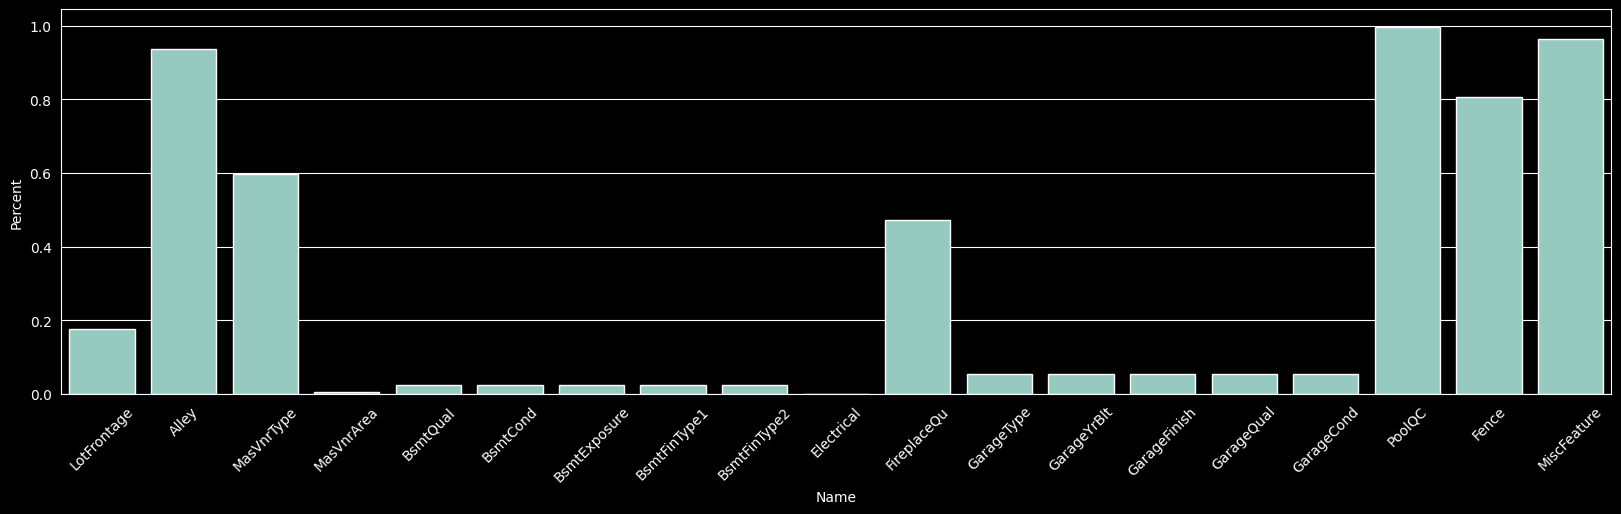

,Name,Percent
0,LotFrontage,0.177397
1,Alley,0.937671
2,MasVnrType,0.597260
3,MasVnrArea,0.005479
4,BsmtQual,0.025342
5,BsmtCond,0.025342
6,BsmtExposure,0.026027
7,BsmtFinType1,0.025342
8,BsmtFinType2,0.026027
9,Electrical,0.000685


In [25]:
nan_factor = pd.DataFrame({
    "Name": data.columns[nans_mask],
    "Percent": data.loc[:, nans_mask].isna().sum().values/data.shape[0]
})

plt.figure(figsize = (20,5))
plt.xticks(rotation = 45)
sns.barplot(x='Name', y='Percent', data=nan_factor)
plt.show()

nan_factor

#### Houses without Garages

In [26]:
data[['GarageFinish', 'GarageYrBlt', 'GarageQual', 'GarageCond', 'GarageType', 'GarageArea']][data.GarageFinish.isna()]

,GarageFinish,GarageYrBlt,GarageQual,GarageCond,GarageType,GarageArea
Id,,,,,,
40,NaN,NaN,NaN,NaN,NaN,0
49,NaN,NaN,NaN,NaN,NaN,0
79,NaN,NaN,NaN,NaN,NaN,0
89,NaN,NaN,NaN,NaN,NaN,0
90,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...
1350,NaN,NaN,NaN,NaN,NaN,0
1408,NaN,NaN,NaN,NaN,NaN,0
1450,NaN,NaN,NaN,NaN,NaN,0


### What to do with Nans?
For `PoolQC`, `MiscFeature`, `Alley`  we have more than `90%` of data as `NaNs` so we will get rid of this features. <br/>
For `LotFrontage` and `MasVnrArea` we will set `NaNs` to `0` as this features realtes to metrics. <br/>
For `Electrical`, `BsmtQual`, `BsmtCond`, `BsmtFinType1`, `BsmtExposure`, `BsmtFinType2` we will delete rows with `NaNs` as there is less than `5%` of data of them. <br/>
For all `Garage` values we will create additional feature to mark if house has garage and set Feature to `NA` <br/>
For `FireplaceQu` and `MasVnrType` we will use simple imputer.


In [27]:
from sklearn.impute import SimpleImputer

# Dropping Columns
new_data = data.drop(['PoolQC', 'MiscFeature', 'Alley'], axis = 1)

#Dropping Rows
new_data.dropna(subset=nan_factor[nan_factor.Percent < 0.05].Name.values, inplace = True)

#Setting to 0
new_data.LotFrontage = data.LotFrontage.fillna(0)
new_data.MasVnrArea = data.MasVnrArea.fillna(0)

#Add Information about Garage
new_data['HasGarage'] = True
new_data.loc[new_data.GarageFinish.isna(), 'HasGarage'] = False

garage_cols = ['GarageFinish', 'GarageYrBlt', 'GarageCond', 'GarageType', 'GarageQual']
new_data[garage_cols] = new_data[garage_cols].fillna('NA')


imp = SimpleImputer(strategy = 'most_frequent', missing_values = np.nan)
new_data.FireplaceQu = imp.fit_transform(new_data[['FireplaceQu']]).ravel()
new_data.Fence = imp.fit_transform(new_data[['Fence']]).ravel()
new_data.MasVnrType = imp.fit_transform(new_data[['MasVnrType']]).ravel()

new_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HasGarage
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,MnPrv,0,2,2008,WD,Normal,208500,True
2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,MnPrv,0,5,2007,WD,Normal,181500,True
3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,MnPrv,0,9,2008,WD,Normal,223500,True
4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,MnPrv,0,2,2006,WD,Abnorml,140000,True
5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,MnPrv,0,12,2008,WD,Normal,250000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,MnPrv,0,8,2007,WD,Normal,175000,True
1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,MnPrv,0,2,2010,WD,Normal,210000,True
1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,GdPrv,2500,5,2010,WD,Normal,266500,True


In [28]:
new_data.isna().sum().sort_values(ascending=False).head(10)

MSSubClass      0
BedroomAbvGr    0
GarageType      0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
HalfBath        0
dtype: int64

## Features Encoding
The decision about data encoding is mostly data and domain specific.

In [29]:
mask = (new_data.dtypes == 'object')
categorical_col = list(mask[mask].index)
new_data[categorical_col]

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,PavedDrive,Fence,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Attchd,2003.0,RFn,TA,TA,Y,MnPrv,WD,Normal
2,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Attchd,1976.0,RFn,TA,TA,Y,MnPrv,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,TA,Attchd,2001.0,RFn,TA,TA,Y,MnPrv,WD,Normal
4,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Detchd,1998.0,Unf,TA,TA,Y,MnPrv,WD,Abnorml
5,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,TA,Attchd,2000.0,RFn,TA,TA,Y,MnPrv,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Attchd,1999.0,RFn,TA,TA,Y,MnPrv,WD,Normal
1457,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,...,TA,Attchd,1978.0,Unf,TA,TA,Y,MnPrv,WD,Normal
1458,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,...,Gd,Attchd,1941.0,RFn,TA,TA,Y,GdPrv,WD,Normal


### How to encode features ?
# Feature Engineering Plan: Ames Housing Dataset

## 1. Ordinal Encoding (Ranked Categories)
These features have a natural progression where one value is objectively "better" or "more" than another.

| Category | Features | Logical Scale (Worst → Best) |
| :--- | :--- | :--- |
| **Quality & Condition** | `ExterQual`, `ExterCond`, `BsmtQual`, `BsmtCond`, `HeatingQC`, `KitchenQual`, `FireplaceQu`, `GarageQual`, `GarageCond` | `NA` (0) < `Po` (1) < `Fa` (2) < `TA` (3) < `Gd` (4) < `Ex` (5) |
| **Basement Finish** | `BsmtFinType1`, `BsmtFinType2` | `NA` < `Unf` < `LwQ` < `Rec` < `BLQ` < `ALQ` < `GLQ` |
| **Basement Exposure** | `BsmtExposure` | `NA` < `No` < `Mn` < `Av` < `Gd` |
| **Garage Finish** | `GarageFinish` | `NA` < `Unf` < `RFn` < `Fin` |
| **Land Slope** | `LandSlope` | `Sev` < `Mod` < `Gtl` |
| **Lot Shape** | `LotShape` | `IR3` < `IR2` < `IR1` < `Reg` |
| **Land Contour** | `LandContour` | `Low` < `HLS` < `Bnk` < `Lvl` |
| **Sale Condition** | `SaleCondition` | `Abnorml` < `Family` < `Alloca` < `AdjLand` < `Normal` < `Partial` |
| **Inherent Numeric** | `OverallQual` | *Already 1-10; no encoding required.* |

---

## 2. One-Hot Encoding (Nominal Categories)
These features are purely descriptive with no mathematical order between categories.

| Group | Features |
| :--- | :--- |
| **Location & Zoning** | `MSZoning`, `Street`, `Neighborhood`, `LotConfig` |
| **Structure & Roof** | `RoofStyle`, `Foundation`, `MasVnrType` |
| **Exterior Finish** | `Exterior1st`, `Exterior2nd` |
| **Internal Systems** | `Heating`, `CentralAir` (Y/N), `Electrical` |
| **Garage & Drive** | `GarageType`, `PavedDrive` |
| **Transaction Type** | `SaleType` |

---

## 3. Specialized Handling & Temporal Data
These features require calculations or specific logic beyond simple label swapping.

* **`GarageYrBlt`**:
    * *Option A (Age):* Create `GarageAge` = `YrSold` - `GarageYrBlt`.
    * *Option B (Binary):* Create `HasGarage` (1 if year exists, 0 if NaN).
* **`CentralAir`**: Simple binary mapping: `{'N': 0, 'Y': 1}`.

---

## 4. Dropped Columns (Low Variance / Redundant)
These columns are removed to reduce noise or because they provide near-zero predictive power (mostly have one value).

| Reason | Features |
| :--- | :--- |
| **Near-Zero Variance** | `Utilities`, `Condition1`, `Condition2`, `RoofMatl`, `Functional` |
| **Redundancy** | `BldgType` (Captured by `HouseStyle`) |
| **Missing Data** | `Fence` (High % of NaNs) |

### Dropping and Encoding

#### Numerical and Ordinal

In [30]:
# TODO: Num Data
num_data = new_data.loc[:, ~mask.values]
encoded_data = pd.DataFrame()

#Quality Data Encoding
quality_col = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
quality_map = {'NA': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
for col in quality_col:
    encoded_data[col] = new_data[col].map(quality_map)

#Basement Finish
bsmt_finish_map = {'NA': 0,  'Unf': 1,'LwQ': 2,'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
encoded_data['BsmtFinType1'] = new_data['BsmtFinType1'].map(bsmt_finish_map)
encoded_data['BsmtFinType2'] = new_data['BsmtFinType2'].map(bsmt_finish_map)

# Exposure
bsmt_exp_map = {'NA': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
encoded_data['BsmtExposure'] = new_data['BsmtExposure'].map(bsmt_exp_map)

#Garage
garage_fin_map = {'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
encoded_data['GarageFinish'] = new_data['GarageFinish'].map(garage_fin_map)

# Land Slope
slope_map = {'Sev': 0, 'Mod': 1, 'Gtl': 2}
encoded_data['LandSlope'] = new_data['LandSlope'].map(slope_map)

# Lot Shape
shape_map = {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3}
encoded_data['LotShape'] = new_data['LotShape'].map(shape_map)

# Land Contour
contour_map = {'Low': 0, 'HLS': 1, 'Bnk': 2, 'Lvl': 3}
encoded_data['LandContour'] = new_data['LandContour'].map(contour_map)

# Sale Condition
sale_cond_map = {'Abnorml': 0, 'Family': 1, 'Alloca': 2, 'AdjLand': 3, 'Normal': 4, 'Partial': 5}
encoded_data['SaleCondition'] = new_data['SaleCondition'].map(sale_cond_map)

encoded_data['OverallQual'] = new_data['OverallQual']


encoded_data

,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,BsmtFinType1,BsmtFinType2,BsmtExposure,GarageFinish,LandSlope,LotShape,LandContour,SaleCondition,OverallQual
Id,,,,,,,,,,,,,,,,,,
1,4,3,4,3,5,4,4,3,3,6,1,1,2,2,3,3,4,7
2,3,3,4,3,5,3,3,3,3,5,1,4,2,2,3,3,4,6
3,4,3,4,3,5,4,3,3,3,6,1,2,2,2,2,3,4,7
4,3,3,3,4,4,4,4,3,3,5,1,1,1,2,2,3,0,7
5,4,3,4,3,5,4,3,3,3,6,1,3,2,2,2,3,4,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,3,3,4,3,5,3,3,3,3,1,1,1,2,2,3,3,4,6
1457,3,3,4,3,3,3,3,3,3,5,3,1,1,2,3,3,4,6
1458,5,4,3,4,5,4,4,3,3,6,1,1,2,2,3,3,4,7


In [31]:
num_data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,HasGarage
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,61,0,0,0,0,0,2,2008,208500,True
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,0,0,0,5,2007,181500,True
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,42,0,0,0,0,0,9,2008,223500,True
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,35,272,0,0,0,0,2,2006,140000,True
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,84,0,0,0,0,0,12,2008,250000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,40,0,0,0,0,0,8,2007,175000,True
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,0,0,0,0,0,0,2,2010,210000,True
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,60,0,0,0,0,2500,5,2010,266500,True


# One-Hot encoded

In [32]:
# Y/N
encoded_data['CentralAir'] = new_data['CentralAir'].map({'Y':True, 'N':False})

nominal_features = [
    'MSZoning', 'Street', 'Neighborhood', 'LotConfig',
    'RoofStyle', 'Foundation', 'MasVnrType',
    'Exterior1st', 'Exterior2nd',
    'Heating', 'Electrical',
    'GarageType', 'PavedDrive',
    'SaleType'
]

one_hot_encoded = pd.get_dummies(new_data[nominal_features])

one_hot_encoded

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,...,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD
Id,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
4,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
5,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1457,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1458,False,False,False,True,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True


# Combine and Save

In [33]:
final_data = pd.concat([num_data, encoded_data, one_hot_encoded], axis='columns')


final_data.to_csv('Data/train_cleaned.csv')

final_data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,PavedDrive_Y,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,True,False,False,False,False,False,False,False,False,True
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,True,False,False,False,False,False,False,False,False,True
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,True,False,False,False,False,False,False,False,False,True
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,True,False,False,False,False,False,False,False,False,True
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,True,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,True,False,False,False,False,False,False,False,False,True
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,True,False,False,False,False,False,False,False,False,True
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,True,False,False,False,False,False,False,False,False,True
